In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


In [3]:
train_dir     ='/kaggle/input/teeth-dataset-cellula/Teeth_Dataset/Training'
validation_dir='/kaggle/input/teeth-dataset-cellula/Teeth_Dataset/Validation'

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

from tensorflow.keras.preprocessing import image_dataset_from_directory

In [7]:
ds_train = image_dataset_from_directory(
    train_dir,
    image_size=(256, 256),  
    batch_size=32,
    label_mode='categorical', 
    shuffle=True
)

Found 3087 files belonging to 7 classes.


In [8]:
ds_val = image_dataset_from_directory(
    validation_dir,
    image_size=(256, 256),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)


Found 1028 files belonging to 7 classes.


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

ds_train = ds_train.cache().prefetch(buffer_size=AUTOTUNE)
ds_val   = ds_val.cache().prefetch(buffer_size=AUTOTUNE)

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = 256
NUM_CLASSES = 7

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Normalization from ResNet
x = preprocess_input(inputs)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)


In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [14]:
history = model.fit(
ds_train,
validation_data=ds_val,
epochs=15
)

Epoch 1/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 460s 5s/step - accuracy: 0.2944 - loss: 2.4891 - val_accuracy: 0.6187 - val_loss: 1.5610
Epoch 2/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 405s 4s/step - accuracy: 0.5470 - loss: 1.6639 - val_accuracy: 0.7189 - val_loss: 1.3283
Epoch 3/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 484s 5s/step - accuracy: 0.6532 - loss: 1.4221 - val_accuracy: 0.7656 - val_loss: 1.1834
Epoch 4/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 404s 4s/step - accuracy: 0.7169 - loss: 1.2573 - val_accuracy: 0.8045 - val_loss: 1.0662
Epoch 5/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 444s 4s/step - accuracy: 0.7649 - loss: 1.1186 - val_accuracy: 0.8366 - val_loss: 0.9799
Epoch 6/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 406s 4s/step - accuracy: 0.8107 - loss: 1.0321 - val_accuracy: 0.8502 - val_loss: 0.9123
Epoch 7/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 405s 4s/step - accuracy: 0.8405 - loss: 0.9354 - val_accuracy: 0.8774 - val_loss: 0.8564
Epoch 8/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 405s 4s/step - accuracy: 0.8445 - loss: 0.8753 - val_accuracy: 0.8940 - v

In [ ]:
# Save the model in Native Keras format
model.save("teeth_classifier_resnet50.keras")



In [17]:
from tensorflow.keras.models import load_model

model = load_model("teeth_classifier_resnet50.keras")


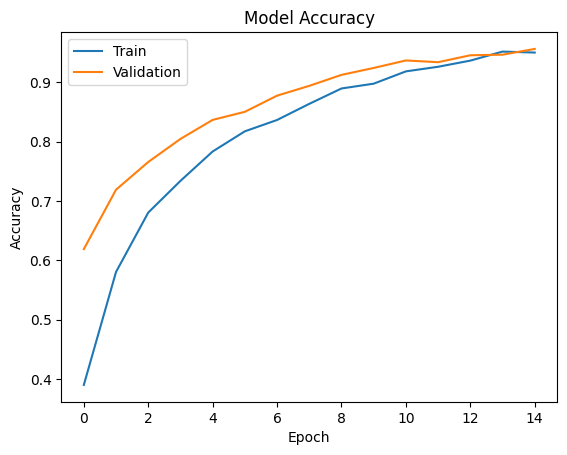

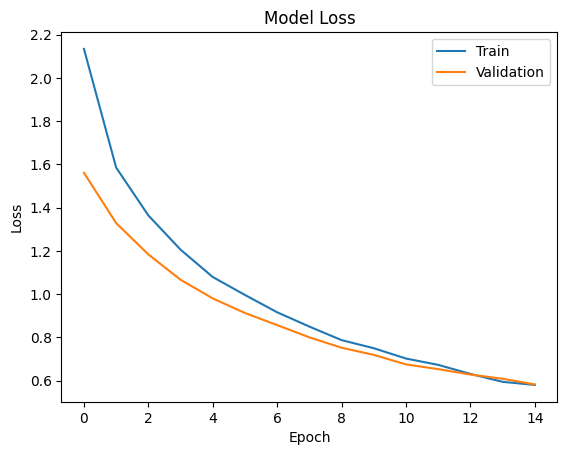

In [18]:
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()


In [23]:

import os

train_dir = '/kaggle/input/teeth-dataset-cellula/Teeth_Dataset/Training'


class_names = sorted([folder for folder in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, folder))])

print("Class Names:", class_names)




Class Names: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']


33/33 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step
              precision    recall  f1-score   support

         CaS       0.97      0.94      0.96       160
         CoS       0.97      1.00      0.98       149
         Gum       0.98      0.92      0.95       120
          MC       0.97      0.94      0.95       180
          OC       0.89      0.99      0.94       108
         OLP       0.94      0.97      0.95       180
          OT       0.98      0.94      0.96       131

    accuracy                           0.96      1028
   macro avg       0.96      0.96      0.96      1028
weighted avg       0.96      0.96      0.96      1028



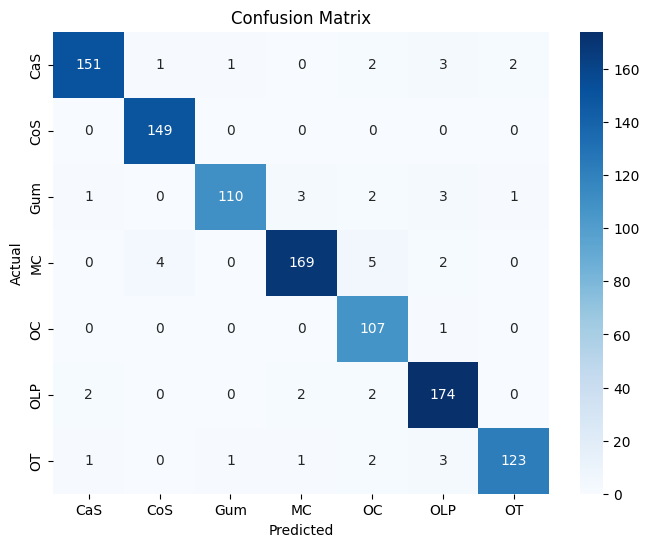

In [24]:
# Classification Report
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_probs = model.predict(ds_val)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = []
for images, labels in ds_val:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
